In [1]:
!pip install pyspark

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.2/317.2 MB 3.9 MB/s eta 0:00:0000:0100:01�━━━━━━━━━╺━━━━━━━━━━━ 218.9/317.2 MB 21.0 MB/s eta 0:00:05
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 9.9 MB/s eta 0:00:00
  Created wheel for pyspark: filename=pyspark-3.5.5-py2.py3-none-any.whl size=317747860 sha256=18c12c20007c6e6ab13528314d6e0a522cef8229a01ce7080c9684d04595a962
  Stored in directory: /home/jovyan/.cache/pip/wheels/0c/7f/b4/0e68c6d8d89d2e582e5498ad88616c16d7c19028680e9d3840
Successfully built pyspark


In [1]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import Tokenizer, HashingTF, IDF, StringIndexer, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml import Pipeline
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession

# Create the Spark session with the required configurations
'''spark = SparkSession.builder \
    .appName("MySparkApp") \
    .config("spark.executor.memory", "12g") \
    .config("spark.driver.memory", "12g") \
    .config("spark.executor.memoryOverhead", "6g") \
    .config("spark.driver.memoryOverhead", "6g") \
    .config("spark.cores.max", "8") \
    .config("spark.task.maxFailures", "5") \
    .config("spark.sql.shuffle.partitions", "200") \
    .getOrCreate()


hdfs_path = "hdfs://namenode:8020/user/hadoop/csv_files"
skills_df = spark.read.csv(hdfs_path + "/job_skills.csv", header=True, inferSchema=True)
postings_df = spark.read.csv(hdfs_path + "/linkedin_job_postings.csv", header=True, inferSchema=True)
summary_df = spark.read.csv(hdfs_path + "/job_summary.csv",header=True, inferSchema=True)'''
#Start Spark Session
spark = SparkSession.builder \
    .appName("Data Analysis-EDA") \
    .getOrCreate()

#Define HDFS Path
hdfs_path = "hdfs://namenode:8020/user/hadoop/csv_datasets/"

#Read CSV Files
skills_df = spark.read.option("header", True).csv(hdfs_path + "job_skills.csv")
postings_df = spark.read.option("header", True).csv(hdfs_path + "linkedin_job_postings.csv")
summary_df = spark.read.option("header", True).csv(hdfs_path + "job_summary.csv")

# Step 3: Show basic info
skills_df.printSchema()
postings_df.printSchema()
summary_df.printSchema()



root
 |-- job_link: string (nullable = true)
 |-- job_skills: string (nullable = true)

root
 |-- job_link: string (nullable = true)
 |-- last_processed_time: string (nullable = true)
 |-- got_summary: string (nullable = true)
 |-- got_ner: string (nullable = true)
 |-- is_being_worked: string (nullable = true)
 |-- job_title: string (nullable = true)
 |-- company: string (nullable = true)
 |-- job_location: string (nullable = true)
 |-- first_seen: string (nullable = true)
 |-- search_city: string (nullable = true)
 |-- search_country: string (nullable = true)
 |-- search_position: string (nullable = true)
 |-- job_level: string (nullable = true)
 |-- job_type: string (nullable = true)

root
 |-- job_link: string (nullable = true)
 |-- job_summary: string (nullable = true)



In [2]:
from pyspark.ml.feature import Tokenizer, HashingTF, IDF, VectorAssembler
from pyspark.ml import Pipeline
from pyspark.sql.functions import col

df = skills_df.join(postings_df, on="job_link", how="inner")
df = df.filter(df["job_skills"].isNotNull())
# Define tokenizer
tokenizer = Tokenizer(inputCol="job_skills", outputCol="words")

# Apply HashingTF or Word2Vec (choose based on preference)
hashing_tf = HashingTF(inputCol="words", outputCol="raw_features", numFeatures=10) #1000
idf = IDF(inputCol="raw_features", outputCol="features")

# Combine features into a single vector
assembler = VectorAssembler(inputCols=["features"], outputCol="final_features")

# Define the pipeline
pipeline = Pipeline(stages=[tokenizer, hashing_tf, idf, assembler])

# Fit and transform the data
processed_data = pipeline.fit(df).transform(df)


In [3]:
sample_data = processed_data.sample(fraction=0.01)
sample_data.show(5)

+--------------------+--------------------+--------------------+-----------+-------+---------------+--------------------+--------------------+--------------------+----------+---------------+--------------+--------------------+----------+--------+--------------------+--------------------+--------------------+--------------------+
|            job_link|          job_skills| last_processed_time|got_summary|got_ner|is_being_worked|           job_title|             company|        job_location|first_seen|    search_city|search_country|     search_position| job_level|job_type|               words|        raw_features|            features|      final_features|
+--------------------+--------------------+--------------------+-----------+-------+---------------+--------------------+--------------------+--------------------+----------+---------------+--------------+--------------------+----------+--------+--------------------+--------------------+--------------------+--------------------+
|https:

In [4]:

from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

# SAMPLE smaller data
sample_small = sample_data.limit(200)

k_values = [5, 6, 7]

best_k = None
best_model = None
best_score = -1

evaluator = ClusteringEvaluator(predictionCol="cluster", featuresCol="final_features")

for k in k_values:
    kmeans = KMeans(k=k, featuresCol="final_features", predictionCol="cluster")
    model = kmeans.fit(sample_small)
    predictions = model.transform(sample_small)
    silhouette = evaluator.evaluate(predictions)
    
    print(f"For k={k}, Silhouette score = {silhouette}")
    
    if silhouette > best_score:
        best_k = k
        best_model = model
        best_score = silhouette

print(f"\nBest k = {best_k} with Silhouette score = {best_score}")

final_predictions = best_model.transform(sample_small)
final_predictions.show(5)


For k=5, Silhouette score = 0.30668263275189966
For k=6, Silhouette score = 0.2772729656751947
For k=7, Silhouette score = 0.2602483238110095

Best k = 5 with Silhouette score = 0.30668263275189966
+--------------------+--------------------+--------------------+-----------+-------+---------------+--------------------+--------------------+--------------------+----------+---------------+--------------+--------------------+----------+--------+--------------------+--------------------+--------------------+--------------------+-------+
|            job_link|          job_skills| last_processed_time|got_summary|got_ner|is_being_worked|           job_title|             company|        job_location|first_seen|    search_city|search_country|     search_position| job_level|job_type|               words|        raw_features|            features|      final_features|cluster|
+--------------------+--------------------+--------------------+-----------+-------+---------------+--------------------+---

In [6]:
from pyspark.ml.clustering import KMeans

sample_data = processed_data
sample_data.show(5)


# Test with a small dataset for clustering
#small_df = sample_data.limit(100)
kmeans = KMeans(k=5, featuresCol="final_features", predictionCol="cluster")
kmeans_model = kmeans.fit(sample_data)
predictions = kmeans_model.transform(sample_data)
predictions.show(5)



+--------------------+--------------------+--------------------+-----------+-------+---------------+--------------------+--------------------+--------------------+----------+------------+--------------+------------------+----------+--------+--------------------+--------------------+--------------------+--------------------+
|            job_link|          job_skills| last_processed_time|got_summary|got_ner|is_being_worked|           job_title|             company|        job_location|first_seen| search_city|search_country|   search_position| job_level|job_type|               words|        raw_features|            features|      final_features|
+--------------------+--------------------+--------------------+-----------+-------+---------------+--------------------+--------------------+--------------------+----------+------------+--------------+------------------+----------+--------+--------------------+--------------------+--------------------+--------------------+
|https://ae.linked...|

In [27]:
from pyspark.ml.evaluation import ClusteringEvaluator

evaluator = ClusteringEvaluator(predictionCol="cluster", featuresCol="final_features")

silhouette = evaluator.evaluate(predictions)
print("Silhouette with squared euclidean distance = " + str(silhouette))


Silhouette with squared euclidean distance = 0.31301874665785384


In [ ]:
import pandas as pd
clustered_data = predictions.select("cluster", "final_features").toPandas()

clustered_data['final_features'] = clustered_data['final_features'].apply(lambda x: x.toArray())

final_features_df = pd.DataFrame(clustered_data['final_features'].to_list(), columns=[f"Feature {i+1}" for i in range(len(clustered_data['final_features'][0]))])

final_features_df['Cluster'] = clustered_data['cluster']


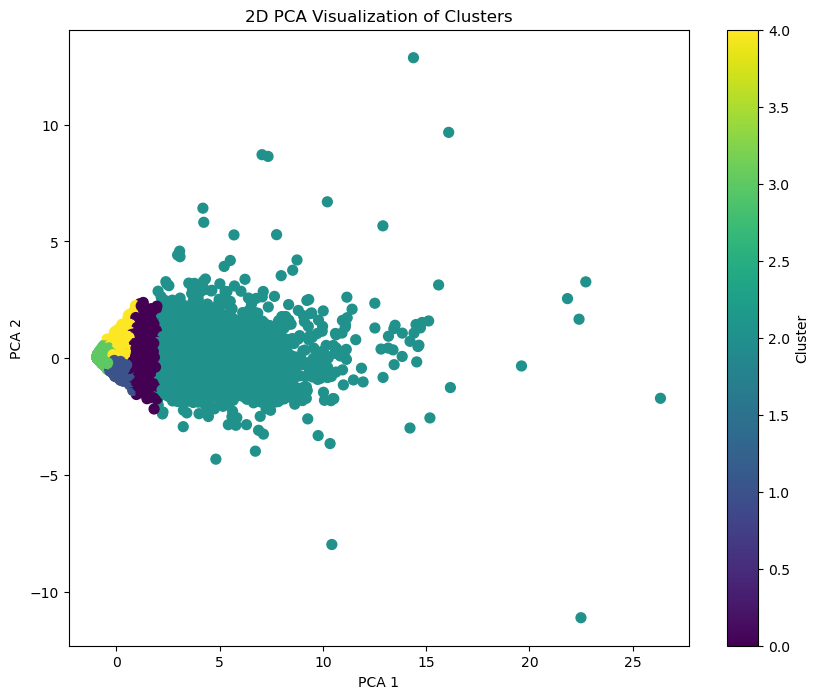

In [30]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
pca_result = pca.fit_transform(final_features_df.drop(columns=["Cluster"]))

final_features_df['PCA1'] = pca_result[:, 0]
final_features_df['PCA2'] = pca_result[:, 1]

plt.figure(figsize=(10, 8))
plt.scatter(final_features_df['PCA1'], final_features_df['PCA2'], c=final_features_df['Cluster'], cmap='viridis', s=50)
plt.title("2D PCA Visualization of Clusters")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(label="Cluster")
plt.show()


In [ ]:
model.bestModel.save("hdfs://namenode:8020/user/hadoop/csv_files/Machine_Learning/models/job_cluster_predictions")

hdfs_path = "hdfs://namenode:8020/user/hadoop/csv_files/Machine_Learning/outputs/job_cluster_predictions"

final_predictions.write.option("header", "true").csv(hdfs_path)